In [20]:
import pandas as pd
import networkx as nx
from github_helper import from_github
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

### Investigating the effects of thresholding
#### In the follwing we try to understand the nature of the network, and the effects yielded by thresholding.
To understand the network we build the graph for the specific network we want to investigate. We then calculate and plot the degree distributions, under different thresholds, and compare it to a selection of commonly observed distributions. We threshold the network as it would otherwise be incredibly dense

In [92]:
def make_specific_graph(topic = "general", period = 71, agg_level = "politician", period_level = "Period", threshold = 0.7):
    topic_df = pd.read_csv(from_github(f"/edges/{agg_level}/{period_level}/{agg_level}_edges_{topic}_by_{period_level}.csv")) 
    period_mask = topic_df[period_level] == period
    specific_df = topic_df[period_mask]
    thresh_df = specific_df[specific_df['weight'] >= threshold]
    G = nx.from_pandas_edgelist(thresh_df, edge_attr= "weight")
    return G

#Define some thresholds for which we want to investigate the degree distributions
thresholds = [0.5, 0.7, 0.8, 0.9]
#Build graphs for the thresholds
graphs = []
for threshold in thresholds:
    G = make_specific_graph(topic = "general", period = 71, agg_level = "politician", period_level = "Period", threshold=threshold)
    graphs.append(G)

#Compute the degree statistics for each threshold
node_stats = []
for node in graphs[0].nodes():
    t50_degree = graphs[0].degree(node)
    t70_degree = graphs[1].degree(node)
    t80_degree = graphs[2].degree(node)
    t90_degree = graphs[3].degree(node)
    node_stats.append((node, t50_degree, t70_degree, t80_degree, t90_degree))
df_stats = pd.DataFrame(node_stats, columns = ["node", "d50", "d70", "d80", "d90"])

#Define a function to plot the series
def fit_and_plot_logbinned(series, ax, title, num_bins=20):
    data_all = np.asarray(series).astype(int)
    data = data_all[data_all > 0]

    # --- Log-binned histogram ---
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), num_bins)
    hist, bin_edges = np.histogram(data, bins=bins)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # geometric mean
    counts = hist
    n = len(data)
    empirical_cdf_x = np.sort(data)
    empirical_cdf_y = np.arange(1, n + 1) / n

    # ---------- POWER-LAW ----------
    log_x = np.log(bin_centers[counts > 0])
    log_y = np.log(counts[counts > 0])
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]
    intercept = np.exp(coeffs[1])
    powerlaw_y = intercept * bin_centers ** (-alpha)

    xmin = data.min()
    sorted_data = empirical_cdf_x
    cdf_powerlaw = 1 - (xmin / sorted_data) ** (alpha - 1)
    ks_powerlaw = np.max(np.abs(empirical_cdf_y - cdf_powerlaw))

    # ---------- LOG-NORMAL ----------
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    lognorm_x = np.linspace(1, data.max(), 200)
    lognorm_pdf = stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    lognorm_y = lognorm_pdf * counts.max() / lognorm_pdf.max()
    ks_lognorm = stats.kstest(data, 'lognorm', args=(shape, loc, scale)).statistic

    # ---------- EXPONENTIAL ----------
    exp_params = stats.expon.fit(data)
    exp_x = np.linspace(1, data.max(), 200)
    exp_pdf = stats.expon.pdf(exp_x, *exp_params)
    exp_y = exp_pdf * counts.max() / exp_pdf.max()
    ks_exp = stats.kstest(data, 'expon', args=exp_params).statistic

    # ---------- POISSON ----------
    lam = data_all.mean()
    p0 = stats.poisson.pmf(0, mu=lam)
    k_vals = np.arange(1, data.max() + 1)
    pois_pmf = stats.poisson.pmf(k_vals, mu=lam)
    pois_pmf_trunc = pois_pmf / (1 - p0)
    pois_y = pois_pmf_trunc * counts.max() / pois_pmf_trunc.max()

    cdf_po_trunc = (stats.poisson.cdf(sorted_data, mu=lam) - p0) / (1 - p0)
    ks_pois = np.max(np.abs(empirical_cdf_y - cdf_po_trunc))

    line_transparency = 0.45

    # ---------- PLOT ----------
    ax.scatter(bin_centers, counts, s=12, color='black', alpha=1, label='Log-binned data')
    ax.plot(bin_centers, powerlaw_y, 'r', lw=1.8, alpha=line_transparency,
            label=f'Power-law (α={alpha:.2f}, KS={ks_powerlaw:.2f})')
    ax.plot(lognorm_x, lognorm_y, 'g', lw=1.8, alpha=line_transparency,
            label=f'Log-normal (KS={ks_lognorm:.2f})')
    ax.plot(exp_x, exp_y, 'b', lw=1.8, alpha=line_transparency,
            label=f'Exponential (KS={ks_exp:.2f})')
    ax.plot(k_vals, pois_y, 'y', lw=1.8, alpha=line_transparency,
            label=f'Poisson (KS={ks_pois:.2f})')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Number of nodes (log)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0.8, top=180) #
    ax.set_xlim(left=5)

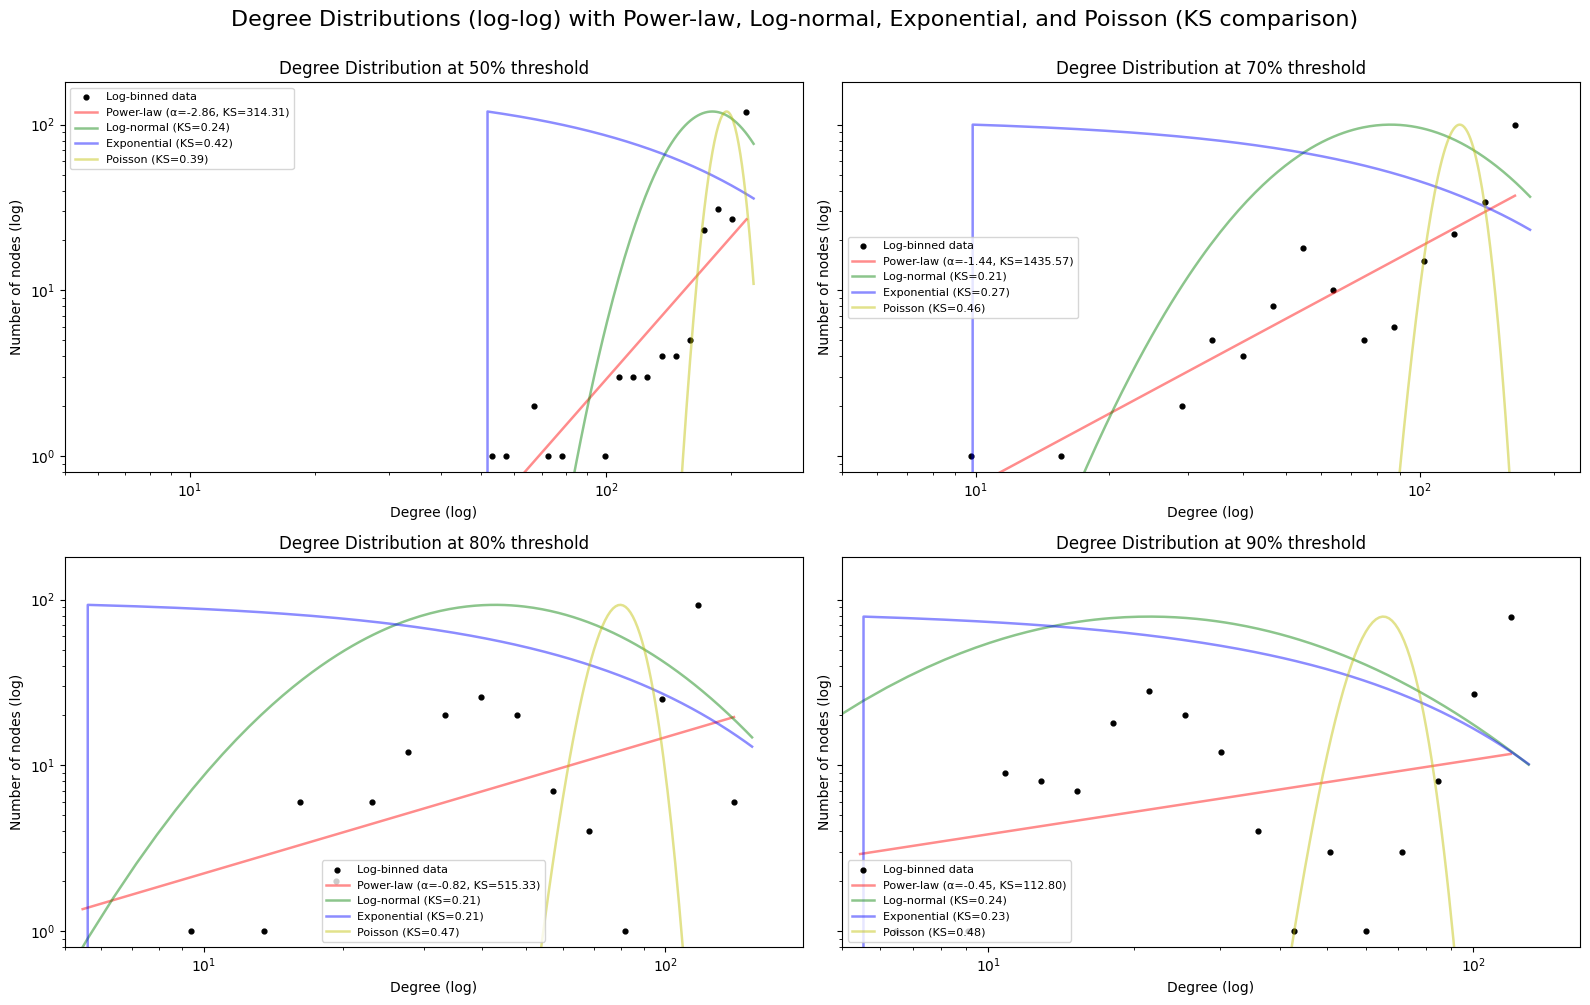

In [93]:
#Now we do the plotting for all four thresholds
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharey=True) #, sharex=True
fit_and_plot_logbinned(df_stats['d50'], axs[0,0], 'Degree Distribution at 50% threshold')
fit_and_plot_logbinned(df_stats['d70'], axs[0,1], 'Degree Distribution at 70% threshold')
fit_and_plot_logbinned(df_stats['d80'], axs[1,0], 'Degree Distribution at 80% threshold')
fit_and_plot_logbinned(df_stats['d90'], axs[1,1], 'Degree Distribution at 90% threshold')

plt.suptitle("Degree Distributions (log-log) with Power-law, Log-normal, Exponential, and Poisson (KS comparison)", y= 1, fontsize = 16)
plt.tight_layout()
plt.show()

>**Figure X:** The plot shows the distributions of the degrees of the Politician Agreement Network in period 71, for all voting-topics, aross 4 different thresholding values. It is compared to the PDF of 4 different distributions, a Power-law Distribution, a Log-Normal Distribution, an Exponential Distribution and a Poisson Distribution. None of the fitted distributions come close to fitting the observed data, as measured by the KS-statistic.